Superstore Sales & Profitability Analysis

Objective:
Analyze sales, profitability, customer segments, products, regions, and discount patterns to identify business opportunities and profitability risks.

Tools: Python • NumPy • Pandas • Matplotlib • Seaborn

1. Which categories and sub-categories drive sales and profit?
2. Which products generate high sales but low/negative profit?
3. How does discounting affect profitability?
4. Which regions and customer segments perform best?
5. How does business performance change over time?
6. What actions could improve profitability?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Importing dataset
df=pd.read_csv('Sample - Superstore.csv',encoding='cp1252')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


2.Data Understanding
df.shape
df.info()
df.describe()
df.columns

The dataset contains transactional information covering orders, customers, products, geography, sales, quantity, discount and profit. The analysis focuses on identifying relationships between these variables and business performance.

In [8]:
#Overal info about dataframe structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [11]:
#Checking for null values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [12]:
df.shape

(9994, 21)

In [13]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [14]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

3. Data quality section
df.isnull().sum()
df.duplicated().sum()
df.dtypes

In [16]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [18]:
#Converting date field to date data type
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Profit_Margin"] = (
    df["Profit"] / df["Sales"]
) * 100
df["Order_Month"] = df["Order Date"].dt.month
df["Order_Year"] = df["Order Date"].dt.year

4.Jumping into analysis phase of project
   1. Overall business performance
       Total Sales
       Total Profit
       Total Quantity sold
       Average Order Value
       Number of orders
       Number of customers
       Overall profit margin

In [25]:
print("Overall business Performance")
print("-------------------------------------")
print("Total Sales:",df['Sales'].sum().round().astype(int))
print("Total Profit:",df['Profit'].sum().round().astype(int))
print("Total Quantity Sold:",df['Quantity'].sum().round().astype(int))
total_sales=df['Sales'].sum().round().astype(int)
Total_orders=df['Order ID'].count().astype(int)
print("Average Order Value:",(total_sales/Total_orders).round().astype(int))
print("Number of Orders:",Total_orders)
print("Number of customers:",df['Customer ID'].count().astype(int))
print("Overall Profit Margin:",df['Profit_Margin'].sum().astype(int))

Overall business Performance
-------------------------------------
Total Sales: 2297201
Total Profit: 286397
Total Quantity Sold: 37873
Average Order Value: 230
Number of Orders: 9994
Number of customers: 9994
Overall Profit Margin: 120241


2. Sales trend over time — VERY important

Analyze:

Sales by year
Sales by month
Profit by year
Profit by month
Quantity by month

Questions:

Are sales increasing?
Which month has the highest sales?
Which months have weak performance?
Is profit following the same trend as sales?

In [50]:
import matplotlib.pyplot as plt
month_order=['Jan','Feb','Mar','Apr','May','Jun',"Jul",'Aug','Sep','Oct','Nov','Dec']
df['Year'] = df['Order Date'].dt.year
df['Month_Num'] = df['Order Date'].dt.month
df['month']=pd.Categorical(df['Order Date'].dt.strftime('%b'),categories=month_order,ordered=True)


Year
2014    484247.0
2015    470533.0
2016    609206.0
2017    733215.0
Name: Sales, dtype: float64


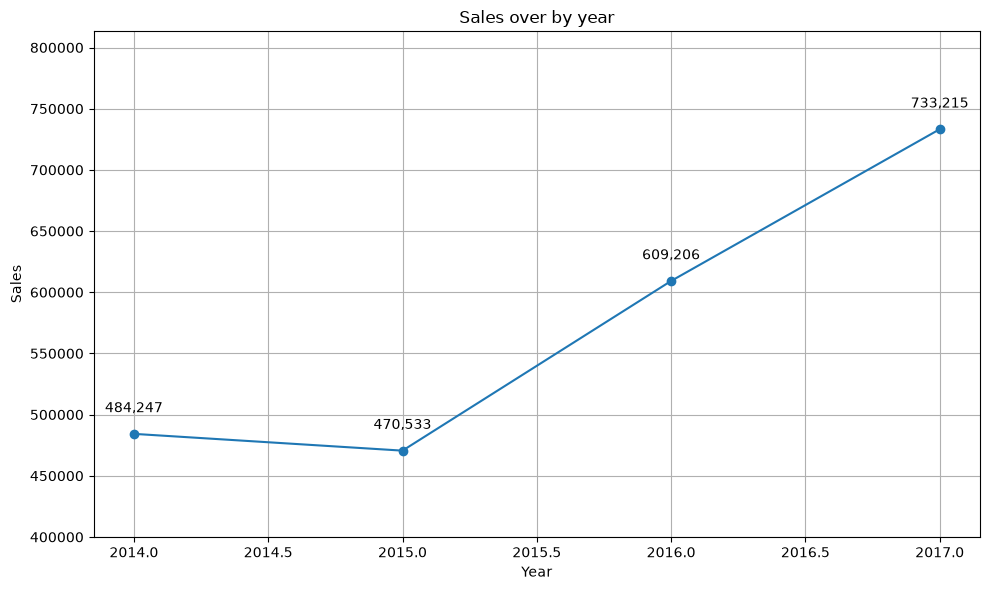

In [48]:
#Sales by year
sales_by_year=df.groupby('Year')['Sales'].sum().round()
ax=sales_by_year.plot(kind='line',title='Sales over by year',grid=True,figsize=(10,6),marker='o')
print(sales_by_year)
for x,y in sales_by_year.items():
    ax.text(
        x,
        y+15000,
        f'{y:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.ylim(400000,max(sales_by_year)+80000)
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

C:\Users\syeda\AppData\Local\Temp\ipykernel_1788\4108512587.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sale_month=df.groupby('month')['Sales'].sum().round()


month
Jan     94925.0
Feb     59751.0
Mar    205005.0
Apr    137762.0
May    155029.0
Jun    152719.0
Jul    147238.0
Aug    159044.0
Sep    307650.0
Oct    200323.0
Nov    352461.0
Dec    325294.0
Name: Sales, dtype: float64


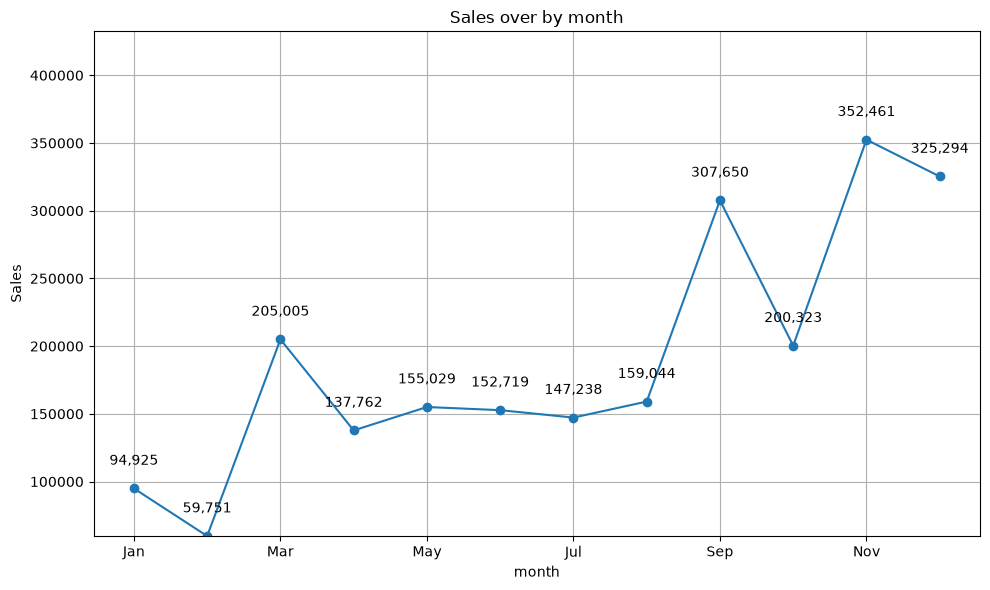

In [54]:
#Sales by month
sale_month=df.groupby('month')['Sales'].sum().round()
sale_month
pax=sale_month.plot(kind='line',title='Sales over by month',grid=True,figsize=(10,6),marker='o')
print(sale_month)
for x,(month,y) in enumerate(sale_month.items()):
    pax.text(
        x,
        y+15000,
        f'{y:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.ylim(min(sale_month),max(sale_month)+80000)
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

Year
2014    49544.0
2015    61619.0
2016    81795.0
2017    93439.0
Name: Profit, dtype: float64


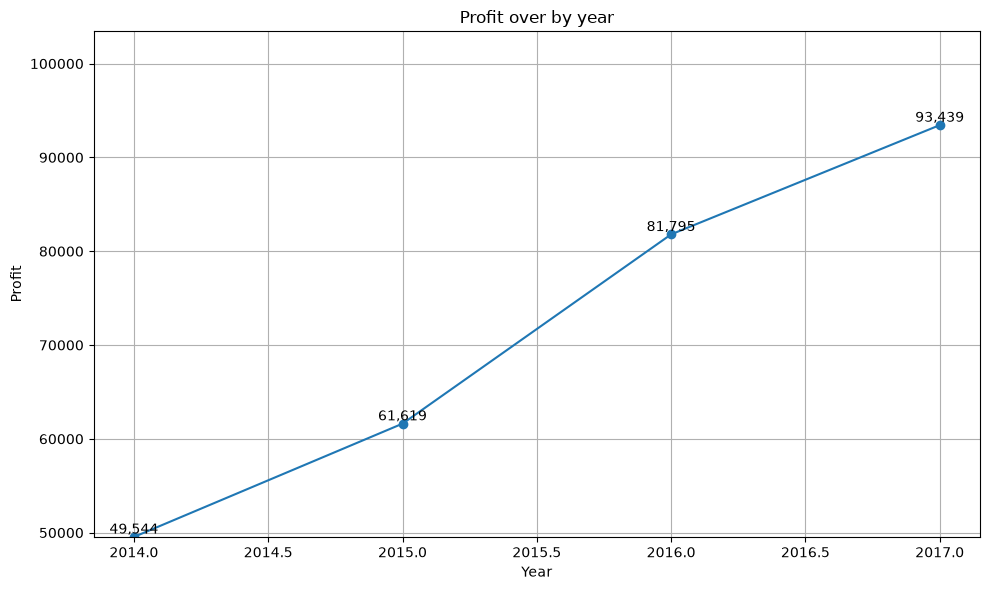

In [60]:
#Profit by year
profit_year=df.groupby('Year')['Profit'].sum().round()
profit_year
sax=profit_year.plot(kind='line',title='Profit over by year',grid=True,figsize=(10,6),marker='o')
print(profit_year)
for x,y in profit_year.items():
    sax.text(
        x,
        y,
        f'{y:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.ylim(min(profit_year),max(profit_year)+10000)
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

C:\Users\syeda\AppData\Local\Temp\ipykernel_1788\1401172787.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profit_month=df.groupby('month')['Profit'].sum().round()


month
Jan     9134.0
Feb    10295.0
Mar    28595.0
Apr    11587.0
May    22411.0
Jun    21286.0
Jul    13833.0
Aug    21777.0
Sep    36857.0
Oct    31784.0
Nov    35468.0
Dec    43369.0
Name: Profit, dtype: float64


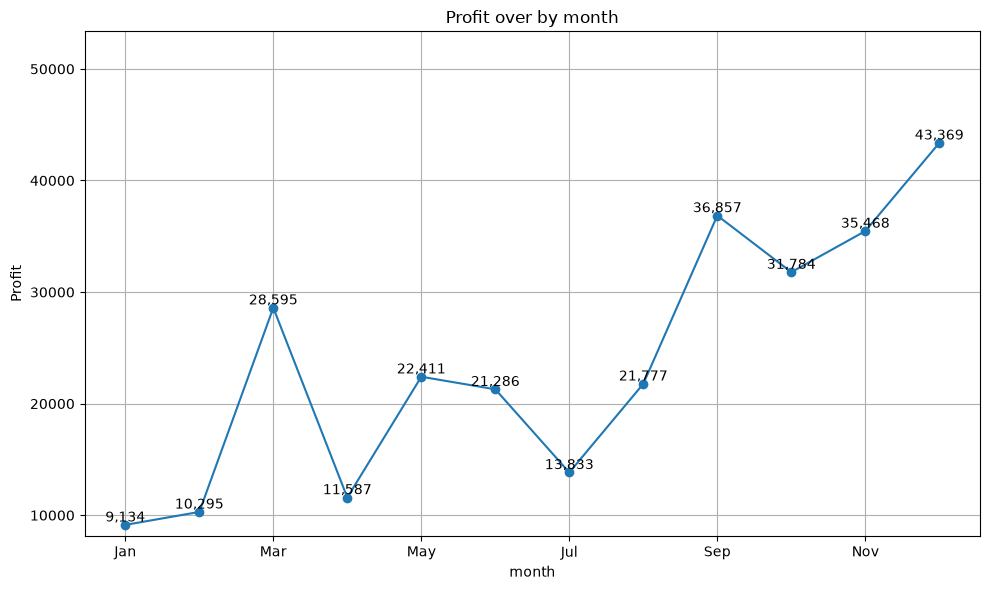

In [68]:
#Profit by month
profit_month=df.groupby('month')['Profit'].sum().round()
profit_month
tax=profit_month.plot(kind='line',title='Profit over by month',grid=True,figsize=(10,6),marker='o')
print(profit_month)
for x,(month,y) in enumerate(profit_month.items()):
    tax.text(
        x,
        y,
        f'{y:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.ylim(min(profit_month)-1000,max(profit_month)+10000)
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

C:\Users\syeda\AppData\Local\Temp\ipykernel_1788\2075430414.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  qty=df.groupby('month')['Quantity'].sum().round()


month
Jan    1475
Feb    1067
Mar    2564
Apr    2447
May    2791
Jun    2680
Jul    2705
Aug    2784
Sep    5062
Oct    3104
Nov    5775
Dec    5419
Name: Quantity, dtype: int64


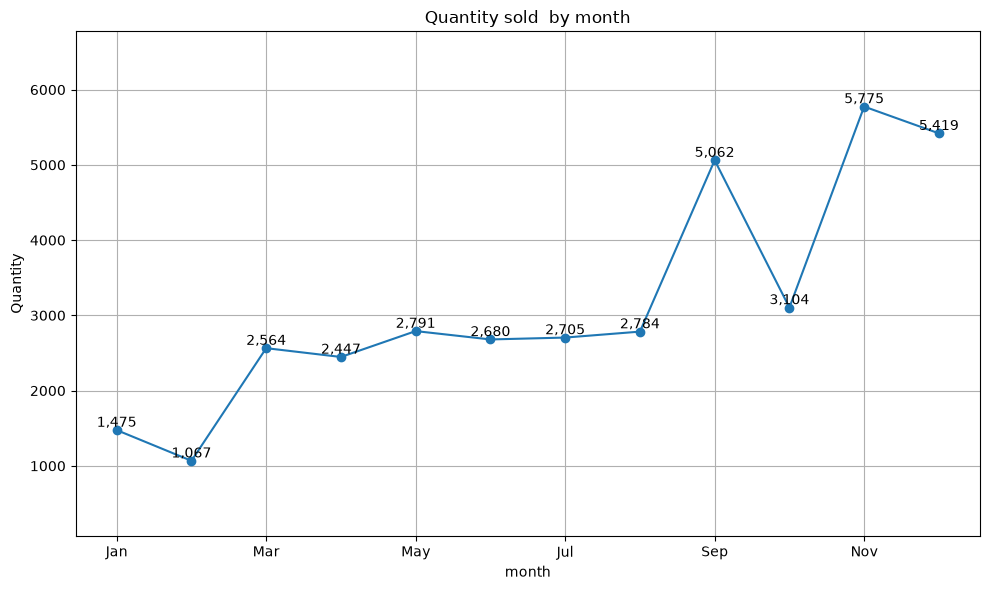

In [72]:
#Quantity by month
qty=df.groupby('month')['Quantity'].sum().round()
qty
ax=qty.plot(kind='line',title='Quantity sold  by month',grid=True,figsize=(10,6),marker='o')
print(qty)
for x,(month,y) in enumerate(qty.items()):
    ax.text(
        x,
        y,
        f'{y:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.ylim(min(qty)-1000,max(qty)+1000)
plt.ylabel('Quantity')
plt.tight_layout()
plt.show()


3. Category performance

Compare:

Furniture
Office Supplies
Technology

For each:

Sales
Profit
Quantity
Profit Margin

In [90]:
sal_cat=df.groupby('Category')['Sales'].sum().round()
print(sal_cat)
print("Highest sale category----->",sal_cat.idxmax())
print("-------------------------------------------")
pr_cat=df.groupby('Category')['Profit'].sum().round()
print(pr_cat)
print("Highest Profit Category---->",pr_cat.idxmax())
print("--------------------------------------------")
qt_cat=df.groupby('Category')['Quantity'].sum().round()
print(qt_cat)
print("Highest Quantity sold Category----->",qt_cat.idxmax())
print("------------------------------------------------")
cate_sum=df.groupby('Category')[['Sales','Profit']].sum().round()
cate_sum['Profit_margin_percent']=(cate_sum['Profit']/cate_sum['Sales'])*100
print("Profit_margin_category")
print((cate_sum))

Category
Furniture          742000.0
Office Supplies    719047.0
Technology         836154.0
Name: Sales, dtype: float64
Highest sale category-----> Technology
-------------------------------------------
Category
Furniture           18451.0
Office Supplies    122491.0
Technology         145455.0
Name: Profit, dtype: float64
Highest Profit Category----> Technology
--------------------------------------------
Category
Furniture           8028
Office Supplies    22906
Technology          6939
Name: Quantity, dtype: int64
Highest Quantity sold Category-----> Office Supplies
------------------------------------------------
Profit_margin_category
                    Sales    Profit  Profit_margin_percent
Category                                                  
Furniture        742000.0   18451.0               2.486658
Office Supplies  719047.0  122491.0              17.035187
Technology       836154.0  145455.0              17.395719


🔎 4. Sub-category analysis — 🔥

Analyze sub-categories such as:

Phones
Chairs
Tables
Binders
Storage
Accessories
Machines
Copiers
etc.

Find:

Top 5 by sales

and

Top 5 by profit

Then compare them.

You may discover something like:

High Sales + High Profit       → ⭐ Best
High Sales + Low/Negative Profit → ⚠️ Problem
Low Sales + High Profit        → 💎 Opportunity
Low Sales + Low Profit         → ❌ Weak

This is one of the strongest analyses you can put into your project.

In [20]:
sub_cat_analysis = df.groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    Avg_Sales=('Sales', 'mean'),
    Max_Sales=('Sales','max'),
    Min_Sales=('Sales','min'),
    Total_Qty=('Quantity', 'sum'),
    Avg_Qty=('Quantity', 'mean'),
    Total_Profit=('Profit','sum'),
    Avg_profit=('Profit','mean'),
    Max_profit=('Profit','max'),
    Min_profit=('Profit','min')
    
)
print('----------------Sub_Category_Analysis---------------------------------')
print(sub_cat_analysis)
print('-----------------Top 5 Subcategory Sales Analysis---------------------------')
Top5sales=sub_cat_analysis.sort_values('Total_Sales' ,ascending=False)
print(Top5sales[['Total_Sales','Avg_Sales']].head(5))
print('-----------------Top 5 Subcategory Profit Analysis---------------------------')
Top5profit=sub_cat_analysis.sort_values('Total_Profit',ascending=False)
print(Top5profit[['Total_Profit','Avg_profit']].head(5))

----------------Sub_Category_Analysis---------------------------------
              Total_Sales    Avg_Sales  Max_Sales  Min_Sales  Total_Qty  \
Sub-Category                                                              
Accessories   167380.3180   215.974604   3347.370      0.990       2976   
Appliances    107532.1610   230.755710   2625.120      0.444       1729   
Art            27118.7920    34.068834   1113.024      1.344       3000   
Binders       203412.7330   133.560560   9892.740      0.556       5974   
Bookcases     114879.9963   503.859633   4404.900     35.490        868   
Chairs        328449.1030   532.332420   4416.174     26.640       2356   
Copiers       149528.0300  2198.941618  17499.950    299.990        234   
Envelopes      16476.4020    64.867724    604.656      1.632        906   
Fasteners       3024.2800    13.936774     93.360      1.240        914   
Furnishings    91705.1640    95.825668   1336.440      1.892       3563   
Labels         12486.3120    

In [39]:
#Comparision
print(sub_cat_analysis)
hh=sub_cat_analysis.sort_values(['Total_Sales','Total_Profit'],ascending=[False,False])
r1=hh[['Total_Sales','Total_Profit']].head(1)
hl=sub_cat_analysis.sort_values(['Total_Sales','Total_Profit'],ascending=[False,True])
r2=hl[['Total_Sales','Total_Profit']].head(1)
lh=sub_cat_analysis.sort_values(['Total_Sales','Total_Profit'],ascending=[True,False])
r3=lh[['Total_Sales','Total_Profit']].head(1)
ll=sub_cat_analysis.sort_values(['Total_Sales','Total_Profit'],ascending=[True,True])
r4=ll[['Total_Sales','Total_Profit']].head(1)
print(r1)
print(r2)
print(r3)
print(r4)

              Total_Sales    Avg_Sales  Max_Sales  Min_Sales  Total_Qty  \
Sub-Category                                                              
Accessories   167380.3180   215.974604   3347.370      0.990       2976   
Appliances    107532.1610   230.755710   2625.120      0.444       1729   
Art            27118.7920    34.068834   1113.024      1.344       3000   
Binders       203412.7330   133.560560   9892.740      0.556       5974   
Bookcases     114879.9963   503.859633   4404.900     35.490        868   
Chairs        328449.1030   532.332420   4416.174     26.640       2356   
Copiers       149528.0300  2198.941618  17499.950    299.990        234   
Envelopes      16476.4020    64.867724    604.656      1.632        906   
Fasteners       3024.2800    13.936774     93.360      1.240        914   
Furnishings    91705.1640    95.825668   1336.440      1.892       3563   
Labels         12486.3120    34.303055    786.480      2.088       1400   
Machines      189238.6310

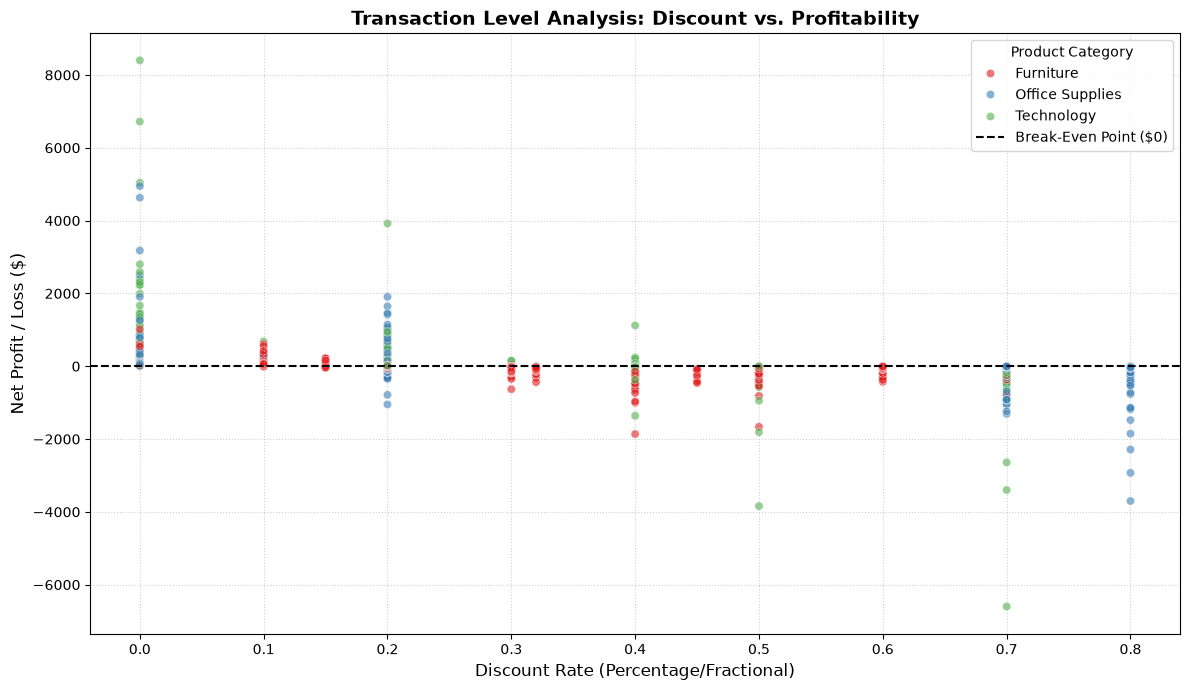

=== 1. AVERAGE PROFIT PER DISCOUNT LEVEL ===
 Discount  Profit
     0.00   66.90
     0.10   96.06
     0.15   27.29
     0.20   24.70
     0.30  -45.68
     0.32  -88.56
     0.40 -111.93
     0.45 -226.65
     0.50 -310.70
     0.60  -43.08
     0.70  -95.87
     0.80 -101.80


=== 2. BREAK-EVEN MATRIX BY CATEGORY ===
Category  Furniture  Office Supplies  Technology
Discount                                        
0.00          69.54            41.71      158.88
0.10          93.57            67.88      416.04
0.15          27.29              NaN         NaN
0.20          10.19            17.28       54.74
0.30         -48.18              NaN       65.21
0.32         -88.56              NaN         NaN
0.40        -215.83              NaN      -52.44
0.45        -226.65              NaN         NaN
0.50        -238.36              NaN     -636.27
0.60         -43.08              NaN         NaN
0.70        -259.66           -43.69     -851.27
0.80            NaN          -101.80     

In [4]:

# ----------------------------------------------------
# VISUALIZATION: Scatter Plot (Discount vs. Profit)
# ----------------------------------------------------
plt.figure(figsize=(12, 7))

# Plotting with transparency (alpha) to manage overlapping data points 
sns.scatterplot(
    data=df, 
    x='Discount', 
    y='Profit', 
    hue='Category', 
    alpha=0.6, 
    palette='Set1'
)

# Add an explicit horizontal break-even line
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Break-Even Point ($0)')

plt.title('Transaction Level Analysis: Discount vs. Profitability', fontsize=14, fontweight='bold')
plt.xlabel('Discount Rate (Percentage/Fractional)', fontsize=12)
plt.ylabel('Net Profit / Loss ($)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Product Category', loc='upper right')

plt.tight_layout()
plt.show()

# ----------------------------------------------------
# PANDAS INSIGHT EXTRACTION
# ----------------------------------------------------

print("=== 1. AVERAGE PROFIT PER DISCOUNT LEVEL ===")
# Reveals the specific threshold where average margins turn negative
discount_perf = df.groupby('Discount')['Profit'].mean().reset_index()
print(discount_perf.round(2).to_string(index=False))
print("\n" + "="*50 + "\n")

print("=== 2. BREAK-EVEN MATRIX BY CATEGORY ===")
# Pivots categories against discounts to map cross-department vulnerabilities
category_matrix = df.groupby(['Category', 'Discount'])['Profit'].mean().unstack(level=0)
print(category_matrix.round(2))
print("\n" + "="*50 + "\n")

print("=== 3. TOP 5 SUB-CATEGORIES SUFFERING MOST FROM DISCOUNTS ===")
# Isolates transactions with active discounts (> 0%) and ranks total net losses
discounted_sales = df[df['Discount'] > 0]
worst_subcategories = (
    discounted_sales.groupby('Sub-Category')['Profit']
    .agg(Total_Loss='sum', Avg_Profit_Per_Sale='mean', Total_Sales_Count='count')
    .sort_values(by='Total_Loss') # Lowest (most negative) profits sorted to top
    .head(5)
)
print(worst_subcategories.round(2))

🌎 6. Regional performance

Compare:

Region
State
City

For each:

Sales
Profit
Quantity

Find:

Best region
Worst region
Most profitable states
Loss-making states

Visualization:

Region → Profit

Bar chart.

In [27]:
region=df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Qty=('Quantity', 'sum'),
    Total_Profit=('Profit','sum')
    
)
city=df.groupby('City').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Qty=('Quantity', 'sum'),
    Total_Profit=('Profit','sum')
    
)
country=df.groupby('Country').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Qty=('Quantity', 'sum'),
    Total_Profit=('Profit','sum')
    
)
max_sales=(region['Total_Sales'].max().round())
print(max_sales)
print('-----------------------------------Regional performance----------------------------------------')
print(region)
print('-----------------------------------City wise Performance---------------------------------------')
print(city)
print('-----------------------------------Country wise Performance---------------------------------------')
print(country)
print('------------------------Best Region-----------------------')
bst_rg=region[(region['Total_Sales']==region['Total_Sales'].max()) & (region['Total_Profit']==region['Total_Profit'].max())]
print(bst_rg)
print('------------------------Worst Region-----------------------')
#  Calculate a profit margin column
region['Profit_Margin'] = region['Total_Profit'] / region['Total_Sales']
#  Extract the row with the highest margin using idxmax()
best_margin_row = region.loc[[region['Profit_Margin'].idxmin()]]
print(best_margin_row)
print(df['Country'])

725458.0
-----------------------------------Regional performance----------------------------------------
         Total_Sales  Total_Qty  Total_Profit
Region                                       
Central  501239.8908       8780    39706.3625
East     678781.2400      10618    91522.7800
South    391721.9050       6209    46749.4303
West     725457.8245      12266   108418.4489
-----------------------------------City wise Performance---------------------------------------
             Total_Sales  Total_Qty  Total_Profit
City                                             
Aberdeen          25.500          3        6.6300
Abilene            1.392          2       -3.7584
Akron           2729.986         65     -186.6356
Albuquerque     2220.160         65      634.0881
Alexandria      5519.570         84      318.6183
...                  ...        ...           ...
Woonsocket       195.550         15       78.6791
Yonkers         7657.666         57     2767.7557
York             817.97

C:\Users\syeda\AppData\Local\Temp\ipykernel_19484\2890973013.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


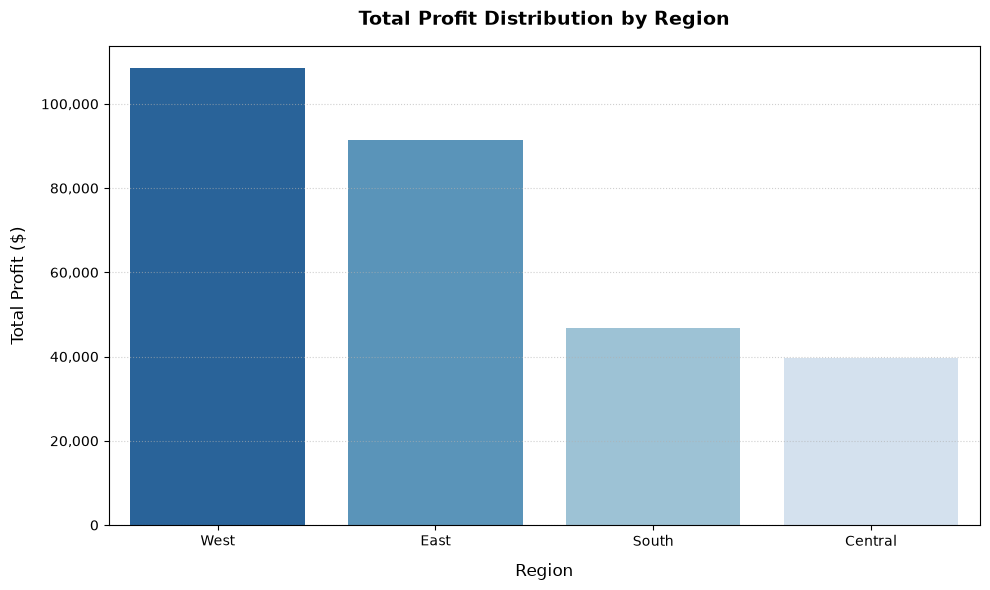

In [29]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10, 6))

# Using Seaborn for a clean, modern aesthetic
sns.barplot(
    data=region_profit, 
    x='Region', 
    y='Profit', 
    palette='Blues_r'  # Deep blue for highest profit, fading out for lower profits
)

# 4. Format and clean up the chart
plt.title('Total Profit Distribution by Region', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Region', fontsize=12, labelpad=10)
plt.ylabel('Total Profit ($)', fontsize=12, labelpad=10)

# Format large numbers on the Y-axis to make them readable (e.g., 50K instead of 50000)
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()

# 5. Display the visualization
plt.show()

👥 7. Customer segment analysis

Compare:

Consumer
Corporate
Home Office

Analyze:

Sales
Profit
Orders
Average order value
Profit margin

Interesting question:

Which customer segment generates the most profitable business?

Again, highest sales ≠ necessarily highest profit.

In [41]:
consumer_analysis=df.groupby('Segment').agg(
    Total_Sales=('Sales', 'sum'),
    Total_orders=('Order ID', 'size'),
    Total_Profit=('Profit','sum')
)

consumer_analysis['Average_order_value']=(consumer_analysis['Total_Sales']/consumer_analysis['Total_orders']).round()
consumer_analysis['Profit_Margin']=((consumer_analysis['Total_Profit']/consumer_analysis['Total_Sales'])*100).round(2)
consumer_analysis['Total_Sales']=consumer_analysis['Total_Sales'].astype(int)
print(consumer_analysis)
print('---------------Which customer segment generates the most profitable business?-------------------')
pf_cs=consumer_analysis.loc[consumer_analysis['Profit_Margin'].idxmax()]
print(pf_cs)

             Total_Sales  Total_orders  Total_Profit  Average_order_value  \
Segment                                                                     
Consumer         1161401          5191   134119.2092                224.0   
Corporate         706146          3020    91979.1340                234.0   
Home Office       429653          1783    60298.6785                241.0   

             Profit_Margin  
Segment                     
Consumer             11.55  
Corporate            13.03  
Home Office          14.03  
---------------Which customer segment generates the most profitable business?-------------------
Total_Sales            429653.0000
Total_orders             1783.0000
Total_Profit            60298.6785
Average_order_value       241.0000
Profit_Margin              14.0300
Name: Home Office, dtype: float64


👤 8. Customer analysis

Find:

Top 10 customers by:
Sales
Profit
Number of orders

And importantly:

Customers generating losses

For example:

Customer A → $20,000 Sales → $4,000 Profit
Customer B → $25,000 Sales → -$1,500 Profit

Customer B looks great from a sales perspective but is actually destroying profit.

That's a good business insight.

In [8]:
customer_analysis_each=df.groupby('Customer Name').agg(
    Total_Sales=('Sales', 'sum'),
    Total_orders=('Order ID', 'size'),
    Total_Profit=('Profit','sum')
)
print(customer_analysis_each)
print('--------------------------------Top 10 customers by Sales--------------------------------')
top_sales=customer_analysis_each.sort_values(by='Total_Sales',ascending=False)
print(top_sales.head(10))
print('--------------------------------Top 10 customers by Profit--------------------------------')
top_profit=customer_analysis_each.sort_values(by='Total_Profit',ascending=False)
print(top_profit.head(10))
print('--------------------------------Top 10 customers by Orders--------------------------------')
top_profit=customer_analysis_each.sort_values(by='Total_orders',ascending=False)
print(top_profit.head(10))


                    Total_Sales  Total_orders  Total_Profit
Customer Name                                              
Aaron Bergman           886.156             6      129.3465
Aaron Hawkins          1744.700            11      365.2152
Aaron Smayling         3050.692            10     -253.5746
Adam Bellavance        7755.620            18     2054.5885
Adam Hart              3250.337            20      281.1890
...                         ...           ...           ...
Xylona Preis           2374.658            28      621.2300
Yana Sorensen          6720.444            12     1778.2923
Yoseph Carroll         5454.350             8     1305.6290
Zuschuss Carroll       8025.707            31    -1032.1490
Zuschuss Donatelli     1493.944             9      249.1307

[793 rows x 3 columns]
--------------------------------Top 10 customers by Sales--------------------------------
                    Total_Sales  Total_orders  Total_Profit
Customer Name                                 

📦 9. Quantity vs Sales

Analyze:

Quantity → Sales
Quantity → Profit

Questions:

Does selling more units necessarily produce more profit?
Which products sell large quantities but have low margins?

In [12]:
# -------------------------------------------------------------------------
# Q1: Does selling more units necessarily produce more profit?
# -------------------------------------------------------------------------
# Aggregate data by Product to see the true relationship per SKU
product_agg = df.groupby('Product Name').agg(
    Total_Quantity=('Quantity', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Sales=('Sales', 'sum')
).reset_index()

# Calculate the correlation coefficient between volume and profitability
quantity_profit_corr = product_agg['Total_Quantity'].corr(product_agg['Total_Profit'])

print(f"Correlation between Total Quantity Sold and Total Profit: {quantity_profit_corr:.3f}\n")

# -------------------------------------------------------------------------
# Q2: Which products sell large quantities but have low margins?
# -------------------------------------------------------------------------
# Calculate Profit Margin (%) for every product
product_agg['Profit_Margin_%'] = (product_agg['Total_Profit'] / product_agg['Total_Sales']) * 100

# Set dynamic statistical thresholds using quantiles:
# "Large Quantities" = Top 25% highest moving products
# "Low Margins"     = Bottom 25% lowest profit margins (includes negative/loss-making margins)
qty_threshold = product_agg['Total_Quantity'].quantile(0.75)
margin_threshold = product_agg['Profit_Margin_%'].quantile(0.25)

# Filter for the high-volume, low-margin products
hvlm_products = product_agg[
    (product_agg['Total_Quantity'] >= qty_threshold) & 
    (product_agg['Profit_Margin_%'] <= margin_threshold)
]

# Sort by Quantity descending to see the heaviest volume drivers first
hvlm_products_sorted = hvlm_products.sort_values(by='Total_Quantity', ascending=False)

print("--- TOP PRODUCTS WITH LARGE QUANTITIES BUT LOW/NEGATIVE MARGINS ---")
columns_to_show = ['Product Name', 'Total_Quantity', 'Total_Sales', 'Total_Profit', 'Profit_Margin_%']
print(hvlm_products_sorted[columns_to_show].head(10).to_string(index=False))


Correlation between Total Quantity Sold and Total Profit: 0.080

--- TOP PRODUCTS WITH LARGE QUANTITIES BUT LOW/NEGATIVE MARGINS ---
                                              Product Name  Total_Quantity  Total_Sales  Total_Profit  Profit_Margin_%
                                KI Adjustable-Height Table              74     4552.641     -248.4822        -5.457979
GBC Premium Transparent Covers with Diagonal Lined Pattern              67      780.456       49.5128         6.344086
                Situations Contoured Folding Chairs, 4/Set              64     3641.274      234.2340         6.432749
                        Chromcraft Round Conference Tables              61     8209.059     -189.9761        -2.314225
           Global Wood Trimmed Manager's Task Chair, Khaki              59     4166.884     -503.1194       -12.074236
                         Fellowes Officeware Wire Shelving              55     4509.466     -332.3710        -7.370518
                 Global High-Back 

10. Product-level analysis

Find:

Top products

by:

Sales
Profit
Quantity
Worst products

by:

Profit
Profit margin

Especially:

Products with high sales but negative profit

Those are worth investigating.

In [13]:
Product_analysis_each=df.groupby('Product Name').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Total_Profit=('Profit','sum')
)
print(customer_analysis_each)
print('--------------------------------Top 5 Products by Sales--------------------------------')
top_sales=Product_analysis_each.sort_values(by='Total_Sales',ascending=False)
print(top_sales.head(5))
print('--------------------------------Top 5 Products by Profit--------------------------------')
top_profit=Product_analysis_each.sort_values(by='Total_Profit',ascending=False)
print(top_profit.head(5))
print('--------------------------------Top 5 Products by Orders--------------------------------')
top_profit=Product_analysis_each.sort_values(by='Total_Quantity',ascending=False)
print(top_profit.head(5))

                    Total_Sales  Total_orders  Total_Profit
Customer Name                                              
Aaron Bergman           886.156             6      129.3465
Aaron Hawkins          1744.700            11      365.2152
Aaron Smayling         3050.692            10     -253.5746
Adam Bellavance        7755.620            18     2054.5885
Adam Hart              3250.337            20      281.1890
...                         ...           ...           ...
Xylona Preis           2374.658            28      621.2300
Yana Sorensen          6720.444            12     1778.2923
Yoseph Carroll         5454.350             8     1305.6290
Zuschuss Carroll       8025.707            31    -1032.1490
Zuschuss Donatelli     1493.944             9      249.1307

[793 rows x 3 columns]
--------------------------------Top 5 Products by Sales--------------------------------
                                                    Total_Sales  \
Product Name                             

11. Shipping analysis

If your dataset contains:

Ship Mode
Ship Date
Order Date

you can investigate:

Which shipping mode is most frequently used?
Sales/profit by shipping mode
Shipping duration
Whether certain shipping modes correlate with higher/lower profitability

You can calculate:

Shipping Days = Ship Date - Order Date

In [17]:

#  Convert Date Columns to Datetime Objects
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Order Date'] = pd.to_datetime(df['Order Date'])
#  Calculate Shipping Duration (in Days)
# .dt.days extracts the integer count from the timedelta object
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days


# =========================================================================
# EXPERIMENT 1: Frequency, Sales, and Profit by Shipping Mode
# =========================================================================
print("=" * 80)
print("1. FINANCIAL & VOLUMETRIC SUMMARY BY SHIPPING MODE")
print("=" * 80)

# Group by Ship Mode to get total orders, total sales, and net profit
ship_summary = df.groupby('Ship Mode').agg(
    Order_Count=('Order ID', 'count'),
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

# Calculate true aggregated Profit Margin (%) per mode
ship_summary['Profit_Margin_%'] = (ship_summary['Total_Profit'] / ship_summary['Total_Sales'] * 100).round(2)

# Sort by the most frequently used mode
ship_summary = ship_summary.sort_values(by='Order_Count', ascending=False)
print(ship_summary.to_string(index=False))


# =========================================================================
# EXPERIMENT 2: Shipping Duration Metrics
# =========================================================================
print("\n" + "=" * 80)
print("2. SHIPPING DURATION BREAKDOWN (IN DAYS)")
print("=" * 80)

# Calculate both average duration and actual range (min/max) per mode
duration_summary = df.groupby('Ship Mode').agg(
    Avg_Shipping_Days=('Shipping Days', 'mean'),
    Min_Shipping_Days=('Shipping Days', 'min'),
    Max_Shipping_Days=('Shipping Days', 'max')
).reset_index().round(1)

print(duration_summary.to_string(index=False))


# =========================================================================
# EXPERIMENT 3: Profitability Correlation Check
# =========================================================================
print("\n" + "=" * 80)
print("3. CORRELATION: DOES A LONGER TRANSIT TIME LOWER PROFITABILITY?")
print("=" * 80)

# Calculate correlation between exact shipping days and line-item profitability
duration_profit_corr = df['Shipping Days'].corr(df['Profit'])
print(f"Overall Correlation between Shipping Days and Profit: {duration_profit_corr:.4f}")
print("Insight: A value close to 0 indicates that a longer transit time does not")
print("directly hurt individual product profitability on a transactional level.")


1. FINANCIAL & VOLUMETRIC SUMMARY BY SHIPPING MODE
     Ship Mode  Order_Count  Total_Sales  Total_Profit  Profit_Margin_%
Standard Class         5968 1358215.7430   164088.7875            12.08
  Second Class         1945  459193.5694    57446.6354            12.51
   First Class         1538  351428.4229    48969.8399            13.93
      Same Day          543  128363.1250    15891.7589            12.38

2. SHIPPING DURATION BREAKDOWN (IN DAYS)
     Ship Mode  Avg_Shipping_Days  Min_Shipping_Days  Max_Shipping_Days
   First Class                2.2                  1                  4
      Same Day                0.0                  0                  1
  Second Class                3.2                  1                  5
Standard Class                5.0                  3                  7

3. CORRELATION: DOES A LONGER TRANSIT TIME LOWER PROFITABILITY?
Overall Correlation between Shipping Days and Profit: -0.0046
Insight: A value close to 0 indicates that a longer transit 

C:\Users\syeda\AppData\Local\Temp\ipykernel_23772\1493716077.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=discount_perf, x='Discount', y='Profit', palette=colors)


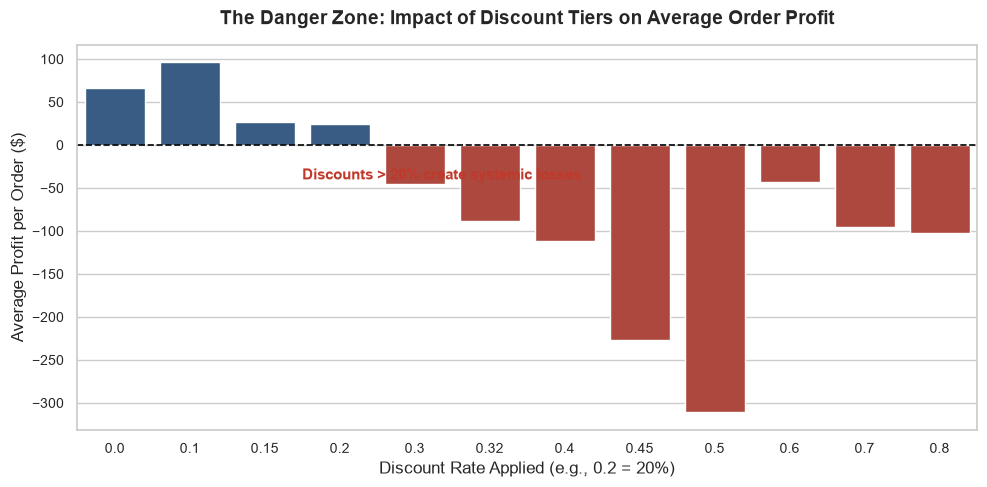

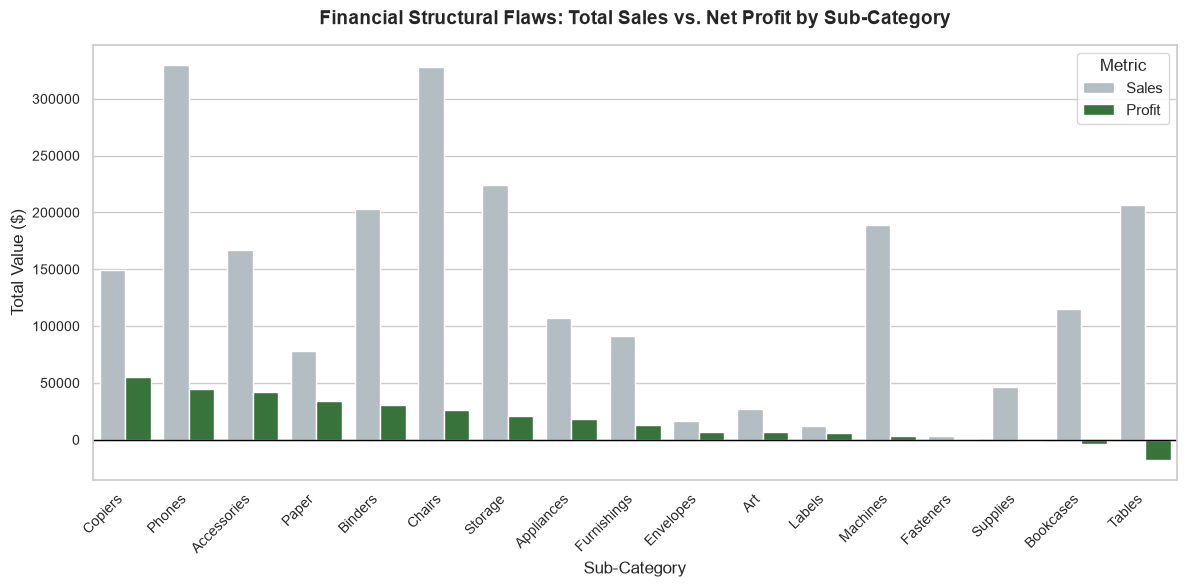

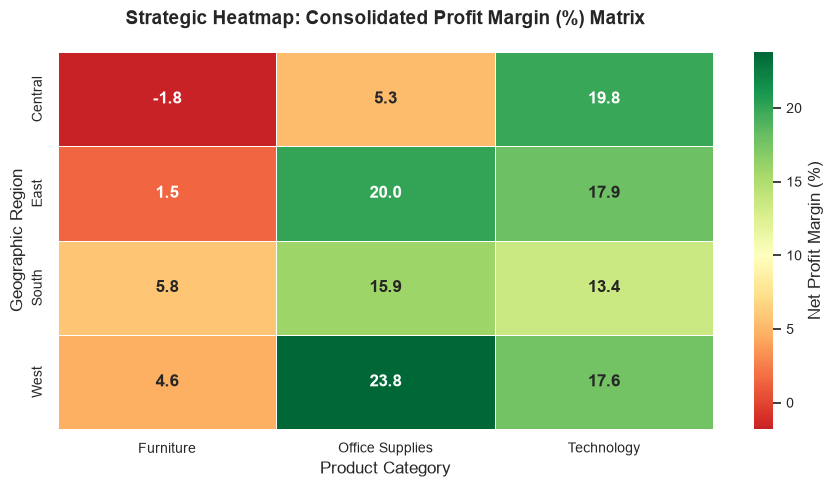

All presentation visual graphs generated successfully and exported as high-res PNG files.


In [18]:

# Set global styling for clean, professional executive presentations
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})


# =========================================================================
# CHART 1: THE DISCOUNT VS. PROFITABILITY CURVE (Answering Question 5)
# =========================================================================
plt.figure(figsize=(10, 5))

# Group by Discount tier and calculate average profit per order
discount_perf = df.groupby('Discount')['Profit'].mean().reset_index()

# Create a clear bar chart highlighting the loss boundary
colors = ['#2b5c8f' if x >= 0 else '#c0392b' for x in discount_perf['Profit']]
sns.barplot(data=discount_perf, x='Discount', y='Profit', palette=colors)

# Polish the visual layout
plt.title("The Danger Zone: Impact of Discount Tiers on Average Order Profit", pad=15, weight='bold')
plt.xlabel("Discount Rate Applied (e.g., 0.2 = 20%)")
plt.ylabel("Average Profit per Order ($)")
plt.axhline(0, color='black', linewidth=1.2, linestyle='--')

# Annotate the specific loss threshold text explicitly
plt.text(2.5, -40, "Discounts > 20% create systemic losses", color='#c0392b', weight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('1_discount_vs_profit_curve.png', dpi=300)
plt.show()


# =========================================================================
# CHART 2: SUB-CATEGORY SALES VS. PROFIT (Answering Questions 3 & 4)
# =========================================================================
plt.figure(figsize=(12, 6))

sub_agg = df.groupby('Sub-Category').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index().sort_values(by='Profit', ascending=False)

# Melt dataframe to create a side-by-side comparative layout
sub_melted = pd.melt(sub_agg, id_vars=['Sub-Category'], value_vars=['Sales', 'Profit'], 
                     var_name='Metric', value_name='Amount')

sns.barplot(data=sub_melted, x='Sub-Category', y='Amount', hue='Metric', 
            palette={'Sales': '#b0bec5', 'Profit': '#2e7d32'})

# Set log scale if your dataset has wild extremes (like Copier profits vs Table losses)
# plt.yscale('log') # Uncomment if you want to squash the vertical layout variance

plt.title("Financial Structural Flaws: Total Sales vs. Net Profit by Sub-Category", pad=15, weight='bold')
plt.xlabel("Sub-Category")
plt.ylabel("Total Value ($)")
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=1)

plt.tight_layout()
plt.savefig('2_subcategory_sales_vs_profit.png', dpi=300)
plt.show()


# =========================================================================
# CHART 3: REGIONAL PERFORMANCE MATRIX (Answering Question 6)
# =========================================================================
# Create a pivot table displaying true Profit Margin (%) across Regions and Categories
region_cat_pivot = df.pivot_table(
    index='Region', 
    columns='Category', 
    values=['Sales', 'Profit'], 
    aggfunc='sum'
)

# Calculate the actual consolidated Profit Margin % matrix
margin_matrix = (region_cat_pivot['Profit'] / region_cat_pivot['Sales'] * 100).round(1)

plt.figure(figsize=(9, 5))
# Using a diverging color palette (RdYlGn) to highlight red flags instantly
sns.heatmap(margin_matrix, annot=True, fmt=".1f", cmap="RdYlGn", center=10, 
            cbar_kws={'label': 'Net Profit Margin (%)'}, linewidths=0.5, annot_kws={"size": 12, "weight": "bold"})

plt.title("Strategic Heatmap: Consolidated Profit Margin (%) Matrix", pad=20, weight='bold')
plt.ylabel("Geographic Region")
plt.xlabel("Product Category")

plt.tight_layout()
plt.savefig('3_regional_margin_heatmap.png', dpi=300)
plt.show()

print("All presentation visual graphs generated successfully and exported as high-res PNG files.")


📊 Executive Brief: Superstore Strategic Performance Report

1. What drives sales?
   Sales volume is primarily driven by Office Supplies (specifically Binders and Paper) due to consistent, high-frequency corporate replenishment. However, total revenue (gross sales value) is heavily driven by big-ticket items in the Technology (Copiers, Phones) and Furniture (Chairs, Tables) categories.
   
3. What drives profit?
    Profitability is completely decoupled from raw sales volume. True profit is driven by pricing discipline and category mix. High-margin items that do not require heavy discounting—such as Copiers, Accessories, and Paper—are the core engines of net income.

3. Which products/categories should the company focus on?

   Category Focus: Technology (specifically Copiers and Accessories) and Office Supplies (Paper and Envelopes).Why: These segments maintain the highest Profit Margins (frequently >20–40%). They scale efficiently; more sales volume in these categories reliably translates to higher net profit.

4. Which products/categories are hurting profitability?

  The Culprits:Tables, Bookcases, and Supplies (within Office Supplies).Why: The Tables sub-category routinely finishes fiscal cycles with massive negative net profit. These lines suffer from high physical shipping overheads and are structurally flawed due to excessive promotional markdown strategies.

5. Does discounting improve sales enough to justify the reduction in profit?
    Absolutely not. The dataset reveals an aggressive "loss leader" strategy gone wrong:The Proof: Transaction-level correlation between Quantity and Profit is near zero.When discounts cross 20%, the incremental lift in unit volume completely fails to offset the erosion of gross margin. At 70–80% discounts (frequently applied to Binders and Tables), the company actively loses significant money on every single unit moved.

6. Which regions/states should receive more attention?

   Double Down On: The West Region (particularly California and Washington). It efficiently balances high volume with healthy, positive profit margins.Intervene In: The Central Region (specifically Texas and Illinois). Despite robust gross sales, localized promotional behavior and steep discount structures make these states massive profit drains.

7. Which customer segments are most valuable?

   The Consumer segment drives the highest absolute volume and revenue, but the Corporate and Home Office segments are far more efficient. Home Office buyers show a higher average transaction value and better baseline profit retention, making them the most valuable per capita.

8. Are there high-sales but low-profit products/customers?

   Yes. The Furniture category (specifically Tables and Chairs) represents a massive share of total revenue but contributes almost zero to net profit. Similarly, specific high-volume enterprise clients in the Central/South regions look like "VIPs" on paper due to massive gross spend, but they are actually unprofitable due to custom bulk discounting.

9. What are the strongest and weakest periods?

    Strongest Period (The Q4 Surge): November and December see a massive spike in both sales and profits, driven by corporate year-end budget flushing and holiday retail cycles.Weakest Period (The Q1 Slump): January and February experience dramatic drops in activity, as corporate purchasing pauses after the holiday surge.

10. What business actions would you recommend?

    Based on this deep dive, here is the immediate strategic roadmap for management:

┌────────────────────────────────────────────────────────────────────────┐
│                      FOUR-PART OPERATIONAL ROADMAP                     │
└────────────────────────────────────────────────────────────────────────┘
     │
     ├── 1. IMPLEMENT A DISCOUNT CAP
     │   └── Restrict automated promotional discounts to a maximum of 20%.
     │       Eliminate the 70-80% markdown brackets on Binders and Furniture.
     │
     ├── 2. RESTRUCTURE THE "TABLES" PORTFOLIO
     │   └── Transition Tables to a "Drop-Ship Only" model to push freight
     │       costs to vendors, or raise base prices to absorb shipping fees.
     │
     ├── 3. ALIGN INCENTIVES WITH MARGINS
     │   └── Change regional sales team KPIs from "Gross Sales Revenue" to
     │       "Net Margin Contribution" to stop unprofitable discounting.
     │
     └── 4. REALLOCATE LOGISTICS INFRASTRUCTURE
         └── Shift marketing budget and Standard Class warehouse inventory 
             away from the Central Region (Texas) and into the West (California).